In [14]:
%load_ext jupyternotify

/home2/pwfb75/joel_jupyterenv-3.9/lib/python3.9/site-packages/jupyternotify/jupyternotify.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


<IPython.core.display.Javascript object>

Dataframe:  
Text ID, Excerpt, Topic, Stance  


import labelling validation, add text, remove the rows without topics, for each subtopic have a separate row for stance, check the characteristics of the test set and use it

In [1]:
import pandas as pd
import numpy as np
import re
from transformers import pipeline
from sklearn.metrics import cohen_kappa_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
stance_val_df = pd.read_csv('labelling_stance.csv')
stance_val_df

,ID,Text,Claim_Labels,Stance_Label
0,0,"So knife crime's going to go up, because the e...","1200, 1211",1211-support
1,1,Of course Gordon Brown's right to say there's ...,"100, 107, 1300, 1302, 600, 602, 603, 1200, 1208","107-against, 602-support, 603-support, 1302-su..."
2,2,"You won't admit the truth, will you? The truth...",NaN,NaN
3,3,"I tell you how we pay for it. We would, for in...","100, 107,",107-against
4,4,"You just, look, there's no point in speculatin...",NaN,NaN
...,...,...,...,...
364,1426,NaN,"100, 103, 1200, 1207, 1900, 1910, 500, 506",1910-support
365,1756,NaN,"1200, 1207",NaN
366,2601,NaN,"1900, 1910, 400, 406, 200, 202, 230","1910-against, 406-support, 202-support"
367,3070,NaN,"1000, 1006",1006-support


In [3]:
all_turns = []
with open('../Identifying Topics/all_turns_shuffled.txt', 'r') as f:
    ftext=f.read()
    all_turns = ftext.split('\n')
all_turns

['0',
 "So knife crime's going to go up, because the evidence is there, Carla. Reduce stop-and-search, knife crime soars.",
 '',
 '1',
 "Of course Gordon Brown's right to say there's a link. Michael, you know this better than we do. You know there's a link between poverty at home and underperformance in the classroom. It's that link which is holding back so many children. That's what's unfair. That link is the link that I want to help solve. We would do it partly through the tax proposals I've talked about earlier, giving people £700 back in their pocket by raising the income tax threshold to £10,000 so that people on ordinary incomes who aren't being helped at the moment are helped. And through our proposal, we call it - it's a slightly technocratic phrase - we call it a pupil premium. It basically means extra money, £2.5 billion. That would, for instance, allow our schools to reduce the average class size in an average primary school down to 20. I have three young children. Two of th

In [4]:
for index, row in stance_val_df.iterrows():
    if pd.isna(row['Text']):        
        new_text = all_turns[all_turns.index(str(row['ID']))+1]
        stance_val_df.at[index, 'Text'] = new_text

In [5]:
stance_val_df

,ID,Text,Claim_Labels,Stance_Label
0,0,"So knife crime's going to go up, because the e...","1200, 1211",1211-support
1,1,Of course Gordon Brown's right to say there's ...,"100, 107, 1300, 1302, 600, 602, 603, 1200, 1208","107-against, 602-support, 603-support, 1302-su..."
2,2,"You won't admit the truth, will you? The truth...",NaN,NaN
3,3,"I tell you how we pay for it. We would, for in...","100, 107,",107-against
4,4,"You just, look, there's no point in speculatin...",NaN,NaN
...,...,...,...,...
364,1426,I think the lady makes a very important point....,"100, 103, 1200, 1207, 1900, 1910, 500, 506",1910-support
365,1756,I've met some of the people who have rightly c...,"1200, 1207",NaN
366,2601,"Well, I share the frustration of both our ques...","1900, 1910, 400, 406, 200, 202, 230","1910-against, 406-support, 202-support"
367,3070,You're saying people voted for 10% tariffs on ...,"1000, 1006",1006-support


In [6]:
stance_val_df = stance_val_df.dropna(subset=['Claim_Labels'])
stance_val_df

,ID,Text,Claim_Labels,Stance_Label
0,0,"So knife crime's going to go up, because the e...","1200, 1211",1211-support
1,1,Of course Gordon Brown's right to say there's ...,"100, 107, 1300, 1302, 600, 602, 603, 1200, 1208","107-against, 602-support, 603-support, 1302-su..."
3,3,"I tell you how we pay for it. We would, for in...","100, 107,",107-against
5,5,I'm just talking numbers. We haven't even ment...,"1400, 1401, 500, 529, 100, 199","1401-support, 529-against"
6,6,We need strong big business in this country. W...,"1800, 1806, 1900, 1910",1910-support
...,...,...,...,...
364,1426,I think the lady makes a very important point....,"100, 103, 1200, 1207, 1900, 1910, 500, 506",1910-support
365,1756,I've met some of the people who have rightly c...,"1200, 1207",NaN
366,2601,"Well, I share the frustration of both our ques...","1900, 1910, 400, 406, 200, 202, 230","1910-against, 406-support, 202-support"
367,3070,You're saying people voted for 10% tariffs on ...,"1000, 1006",1006-support


In [7]:
def process_stance_data(df):
    df['Claim_Labels'] = df['Claim_Labels'].fillna('').astype(str).str.split(r'\s*,\s*')
    df['Stance_Label'] = df['Stance_Label'].fillna('').astype(str).str.split(r'\s*,\s*')

    def filter_labels(label_list):
        return [
            item for item in label_list 
            if item.isdigit() and int(item) % 100 != 0
        ]

    df['Claim_Labels'] = df['Claim_Labels'].apply(filter_labels)

    df = df.explode('Claim_Labels')
    df = df.dropna(subset=['Claim_Labels'])
    df = df[df['Claim_Labels'] != '']

    def get_specific_stance(row):
        claim = str(row['Claim_Labels'])
        stances = row['Stance_Label']
        
        for s in stances:
            if s.startswith(f"{claim}-"):
                return s.split('-')[1]
        return 'neutral'

    df['Stance'] = df.apply(get_specific_stance, axis=1)

    return df.drop(columns=['Stance_Label']).reset_index(drop=True)

In [8]:
tmp_df = stance_val_df.copy()
tmp_df = process_stance_data(tmp_df)
tmp_df = tmp_df[tmp_df['Claim_Labels'] != '199']
tmp_df = tmp_df[tmp_df['Claim_Labels'] != '399']
tmp_df

,ID,Text,Claim_Labels,Stance
0,0,"So knife crime's going to go up, because the e...",1211,support
1,1,Of course Gordon Brown's right to say there's ...,107,against
2,1,Of course Gordon Brown's right to say there's ...,1302,support
3,1,Of course Gordon Brown's right to say there's ...,602,support
4,1,Of course Gordon Brown's right to say there's ...,603,support
...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support
535,2601,"Well, I share the frustration of both our ques...",230,neutral
536,3070,You're saying people voted for 10% tariffs on ...,1006,support
537,3356,I think this question of enthusiasm is really ...,2032,support


In [9]:
stance_df = tmp_df.copy()

In [10]:
stance_df

,ID,Text,Claim_Labels,Stance
0,0,"So knife crime's going to go up, because the e...",1211,support
1,1,Of course Gordon Brown's right to say there's ...,107,against
2,1,Of course Gordon Brown's right to say there's ...,1302,support
3,1,Of course Gordon Brown's right to say there's ...,602,support
4,1,Of course Gordon Brown's right to say there's ...,603,support
...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support
535,2601,"Well, I share the frustration of both our ques...",230,neutral
536,3070,You're saying people voted for 10% tariffs on ...,1006,support
537,3356,I think this question of enthusiasm is really ...,2032,support


In [14]:
def ds(k):
    if 'support' in k:
        return 'support'
    elif 'neutral' in k:
        return 'neutral'
    elif 'against' in k:
        return 'against'

In [15]:
stance_df['Stance']=stance_df['Stance'].apply(ds)

In [16]:
def get_basic_summaries(df):
    total_annotations = len(df)
    unique_texts = df['ID'].nunique()
    unique_claims = df['Claim_Labels'].nunique()
    
    print("--- Basic Dataset Summaries ---")
    print(f"Total Labels Applied: {total_annotations}")
    print(f"Unique Text Excerpts: {unique_texts}")
    print(f"Unique Claim Categories: {unique_claims}")
    print(f"Average Labels per Excerpt: {total_annotations / unique_texts:.2f}")

get_basic_summaries(stance_df)

--- Basic Dataset Summaries ---
Total Labels Applied: 537
Unique Text Excerpts: 302
Unique Claim Categories: 86
Average Labels per Excerpt: 1.78


In [17]:
def get_stance_distribution(df):
    stance_counts = df['Stance'].value_counts()
    stance_pct = df['Stance'].value_counts(normalize=True) * 100
    
    summary_df = pd.DataFrame({
        'Count': stance_counts,
        'Percentage (%)': stance_pct
    })
    
    print("\n--- Stance Distribution ---")
    print(summary_df.round(2))
    return summary_df

get_stance_distribution(stance_df)


--- Stance Distribution ---
         Count  Percentage (%)
Stance                        
support    329           61.27
against    156           29.05
neutral     52            9.68


,Count,Percentage (%)
Stance,,
support,329,61.266294
against,156,29.050279
neutral,52,9.683426


In [19]:
def get_top_claims(df, n=5):
    # Group by label and stance to see the most frequent pairings
    top_claims = df.groupby(['Claim_Labels', 'Stance']).size().unstack(fill_value=0)
    top_claims['Total'] = top_claims.sum(axis=1)
    
    print(f"\n--- Top {n} Claim Labels (by frequency) ---")
    print(top_claims.sort_values(by='Total', ascending=False).head(n))

get_top_claims(stance_df)


--- Top 5 Claim Labels (by frequency) ---
Stance        against  neutral  support  Total
Claim_Labels                                  
107                22        3       21     46
1910               16        7       20     43
105                15        0       26     41
230                26        4        1     31
301                 0        2       17     19


In [16]:
definitions = {
    101: {"support": "Discussion of the importance of lowering inflation/interest rates", "against": "Downplaying the importance of inflation/interest rate falls"},
    103: {"support": "", "against": ""},
    104: {"support": "Emphasising the importance of the Bank of England and Treasury", "against": "Disregard for the Bank of England or Treasury"},
    105: {"support": "Greater public spending", "against": "Lower public spending"},
    107: {"support": "Tax increases", "against": "Tax reductions"},
    108: {"support": "Support for nationalisation, or opposition to privatisation", "against": "Opposition to nationalisation"},
    201: {"support": "Speaking against racial discrimination, recognising discrimination as a problem", "against": "Downplaying the importance of racial discrimination"},
    202: {"support": "Recognising gender/sexual orientation discrimination as a problem", "against": "Downplaying importance of gender/sexual orientation discrimination"},
    207: {"support": "Support for freedom of expression, including protest. Also, freedom of religion", "against": "Opposition to freedom-of-speech actions such as protests"},
    208: {"support": "Supporting the need to preserve privacy and rights against government interference", "against": "Prioritising security needs over the need for privacy"},
    230: {"support": "Support for immigrants (that would be blocked by strict border control)", "against": "Opposition to immigration"},
    301: {"support": "Support for reforming healthcare", "against": "Support for the NHS as it is, speaking favourably about the NHS without requiring reform"},
    321: {"support": "Support for regulation of the drug industry and control of NHS costs to third parties", "against": "Opposition to drug industry regulation"},
    325: {"support": "Calls for more health staff, or support for the work of health staff", "against": "Criticism of the work of health staff"},
    331: {"support": "Promoting danger of communicable diseases and advocating measures to combat them", "against": "Downplaying the effect of communicable diseases and resisting measures to combat them"},
    332: {"support": "", "against": ""},
    334: {"support": "", "against": ""},
    344: {"support": "Support for drug, alcohol, or substance abuse treatment. Addicts seen as victims", "against": "Focus on law enforcement against drug, alcohol, or substance abusers. Addicts seen as perpetrators"},
    401: {"support": "Support for British agriculture and/or farmers", "against": "Promotion of measures against farming interests"},
    406: {"support": "Support for policies promoting animal welfare", "against": "Downplaying animal welfare concerns"},
    408: {"support": "Support for policies promoting the fishing industry", "against": "Promotion of measures against fishing interests"},
    502: {"support": "Increasing the number of jobs", "against": "Prioritising other concerns over job creation"},
    503: {"support": "Supporting the protection of employee benefits like pensions", "against": "Prioritising other concerns over employee benefits"},
    504: {"support": "Greater negotiation with labour unions", "against": "Opposition to/criticism of labour unions"},
    505: {"support": "Support for higher wages, 'better' working conditions", "against": "Opposition to wage increases"},
    506: {"support": "Increasing youth employment rates", "against": "Arguments against youth employment"},
    508: {"support": "In support of greater investment in childcare", "against": "Rejecting need for increased investment in childcare"},
    529: {"support": "More migrant workers", "against": "Reducing or restricting the number of migrant workers"},
    601: {"support": "Support for actions improving access to higher education, e.g. lowering tuition fees", "against": "Opposition to higher education changes"},
    602: {"support": "Support for investment in schools, or for the work of schools", "against": "Opposition to increased investment in schools"},
    603: {"support": "More investment in education for underprivileged students", "against": "Opposition to increased investment in underprivileged students"},
    604: {"support": "Support of vocational education programs such as apprenticeships", "against": "Criticism of vocational education"},
    606: {"support": "Support for special needs education (as opposed to integration in mainstream schools)", "against": "Arguments for integration of mainstream integration of children with special needs"},
    701: {"support": "", "against": ""},
    703: {"support": "", "against": ""},
    705: {"support": "In support of efforts to limit air pollution, noise pollution, or climate change (or global warming)", "against": "Against efforts to limit air pollution or climate change"},
    709: {"support": "Prioritising the protection of species or forests", "against": "Deprioritising protection of species or forests"},
    801: {"support": "Support for nuclear energy", "against": "Against nuclear energy"},
    803: {"support": "Support for investment in oil and gas exploration", "against": "Against oil and gas exploration"},
    805: {"support": "Support for coal energy and/or the coal industry", "against": "Against coal energy"},
    806: {"support": "Support for alternative and renewable energy", "against": "Against renewable energy initiatives"},
    807: {"support": "Support for efforts to conserve energy, e.g. turning off lights", "against": "Criticism of energy conservation"},
    1001: {"support": "Advocacy for public transportation", "against": "Downplaying the value of public transportation"},
    1002: {"support": "Support for road construction/maintenance projects", "against": "Opposition to road construction projects"},
    1003: {"support": "Support for air travel", "against": "Against air travel"},
    1005: {"support": "Support for train/rail travel", "against": "Criticism of train travel"},
    1006: {"support": "Support for car travel/the automobile industry", "against": "Against car travel"},
    1202: {"support": "Support for strong measures targeting white collar crime", "against": "Downplaying importance of tackling white collar crime"},
    1203: {"support": "Support for greater drug law enforcement", "against": "Opposition to drug law enforcement. Promotion of legalisation arguments"},
    1205: {"support": "Support for more imprisonment and/or higher sentences", "against": "Opposition to greater imprisonment"},
    1206: {"support": "Support for juvenile detention", "against": "Opposition to juvenile detention"},
    1207: {"support": "", "against": ""},
    1208: {"support": "", "against": ""},
    1209: {"support": "Greater investment in the police, or support of the police's work", "against": "Calls for police budget cuts or criticism of police operations"},
    1211: {"support": "More power to police for crime prevention, supporting measures like stop-and-search", "against": "Opposing the expansion of physical police powers such as stop-and-search"},
    1302: {"support": "More assistance for low income families", "against": "Opposition to increasing welfare or subsidies for low income families"},
    1303: {"support": "More investment in the elderly", "against": "Criticism of excessive spending on the elderly"},
    1304: {"support": "Support for providing social welfare to the disabled", "against": "Opposition to expanding social welfare for the disabled"},
    1305: {"support": "Support for the work of charitable organisations", "against": "Criticism of the role or influence of charitable organisations"},
    1401: {"support": "Support for an increase in number of homes being built", "against": "Opposition to new housing developments"},
    1406: {"support": "More housing support for low and middle income families", "against": "Opposition to government-funded housing support"},
    1407: {"support": "More housing assistance for veterans", "against": "Opposition to specific housing for veterans"},
    1409: {"support": "More housing assistance for the homeless", "against": "Opposition to housing programs for the homeless"},
    1410: {"support": "Support for mortgages or home ownership", "against": "Criticism of mortgage support"},
    1501: {"support": "Greater banking regulation", "against": "Support for deregulation or less oversight of the banking sector"},
    1521: {"support": "Prioritising small business concerns", "against": "Deprioritising small business needs"},
    1524: {"support": "Support for tourism", "against": "Opposition to tourism growth"},
    1603: {"support": "Speaking in support of the military intelligence services, e.g. M15", "against": "Criticism of intelligence services"},
    1608: {"support": "Support for strengthening the military", "against": "Advocacy for reduced defence spending"},
    1609: {"support": "Support for veterans", "against": "Opposition to benefits or special status for veterans"},
    1610: {"support": "Supporting the acquisition and/or maintenance of weapons", "against": "Opposing the purchase or upkeep of military weapons"},
    1627: {"support": "Support for measures taken against terrorism", "against": "Criticism of counter-terrorism measures"},
    1803: {"support": "Support for greater British export", "against": "Against greater export"},
    1806: {"support": "Positive comments about UK business in comparison to non-UK", "against": "Negative comments about UK business"},
    1901: {"support": "Support for offering aid to other countries", "against": "Opposition to foreign aid or calls to reduce international spending"},
    1907: {"support": "In support of cooperation with China", "against": "Against cooperation with China"},
    1909: {"support": "In support of Eastern European countries", "against": "Criticism of Eastern European nations"},
    1910: {"support": "Greater cooperation with European partners and staying in the European Union", "against": "Opposing cooperation with European partners"},
    1911: {"support": "In support of helping or intervening in African nations", "against": "Against providing support or intervention in African nations"},
    1920: {"support": "In support of intervention in the Middle East", "against": "Opposing intervention or military presence in the Middle East"},
    1926: {"support": "Collaboration with non-finance international organisations like the UN", "against": "Opposition to working with the UN or similar international bodies"},
    1930: {"support": "Speaking favourably about North America, or North American leaders such as the US President", "against": "Speaking unfavourably about North America or the US President"},
    2001: {"support": "Greater devolution powers for regions", "against": "Opposing devolution or supporting more centralised government"},
    2011: {"support": "Keeping parliamentary operations as they are, against reforms such as abolishing the Lords", "against": "Supporting reform of parliamentary operations, e.g. the abolition of the Lords"},
    2012: {"support": "Speaking favourably about political parties or campaigns", "against": "Speaking negatively about political parties or specific campaigns"},
    2032: {"support": "Emphasising the negative effect of ministerial scandals", "against": "Downplaying or dismissing the impact of ministerial scandals"},
}

In [17]:
titles = {
    100: "Macroeconomics",
    101: "Inflation, prices, and interest rates",
    103: "Unemployment rate",
    104: "Monetary Supply, Central Bank, and the Treasury",
    105: "National Budget, Debt, public spending",
    107: "Taxation, Tax policy, and Tax Reform",
    108: "Industrial Policy, Privatisation, Nationalisation",
    200: "Civil Rights",
    201: "Ethnic Minority and Racial Group Discrimination",
    202: "Gender and Sexual Orientation Discrimination",
    207: "Freedom of Speech & Religion",
    208: "Right to Privacy and Access to Government Information",
    230: "Immigration",
    300: "Health",
    301: "Health Care Reform",
    321: "Regulation of Drug Industry, Medical Devices, and Clinical Labs",
    325: "Health Manpower and Training",
    331: "Prevention, Communicable Diseases and Health Promotion",
    332: "Infants and Children",
    334: "Long-Term Care, Home Health, and Rehabilitation",
    344: "Drug and Alcohol or Substance Abuse Treatment",
    400: "Agriculture",
    401: "Agricultural Trade",
    406: "Animal Welfare",
    408: "Fisheries and Fishing",
    500: "Labour and Employment",
    502: "Employment Training and Workforce Development",
    503: "Employee Benefits",
    504: "Employee Relations and Labour Unions",
    505: "Fair Labour Standards",
    506: "Youth Employment and Child Labour",
    508: "Parental Leave and Child Care",
    529: "Migrant and Seasonal Workers",
    600: "Education",
    601: "Higher Education",
    602: "Elementary and Secondary Education",
    603: "Education of Underprivileged Students",
    604: "Vocational Education",
    606: "Special Education",
    700: "Environment",
    701: "Water Pollution",
    703: "Waste Disposal",
    705: "Air Pollution, Global Warming, and Noise Pollution",
    709: "Species and Forest Protection",
    800: "Energy",
    801: "Nuclear Energy and Nuclear Regulatory Issues",
    803: "Natural Gas and Oil",
    805: "Coal",
    806: "Alternative and Renewable Energy",
    807: "Energy Conservation",
    1000: "Transportation",
    1001: "Mass and Public Transportation and Safety",
    1002: "Highway (Road) Construction, Maintenance, and Safety",
    1003: "Airports, Airlines, Air Traffic Control and Safety",
    1005: "Railroad Transportation and Safety",
    1006: "Truck and Automobile Transportation and Safety",
    1200: "Law, Crime, and Family Issues",
    1202: "White Collar Crime and Organized Crime",
    1203: "Illegal Drug Production, Trafficking, and Control",
    1205: "Prison System",
    1206: "Juvenile Crime and the Juvenile Justice System",
    1207: "Child Abuse",
    1208: "Family Issues",
    1209: "Police, Fire, and Weapons Control",
    1211: "Riots and Crime Prevention",
    1300: "Social Welfare",
    1302: "Poverty and Assistance for Low-Income Families",
    1303: "Elderly Issues and Elderly Assistance Programs, State Pensions",
    1304: "Assistance to the Disabled and Handicapped",
    1305: "Social Services and Volunteer Associations",
    1400: "Planning and Housing Issues",
    1401: "Housing and Community Development",
    1406: "Low and Middle Income Housing Programs and Needs",
    1407: "Veterans Housing Assistance and Military Housing Programs",
    1409: "Housing Assistance for Homeless and Homeless Issues",
    1410: "Mortgages",
    1500: "Finance and Domestic Commerce",
    1501: "Banking System and Financial Institution Regulation",
    1521: "Small Business Issues",
    1524: "Tourism",
    1600: "Defence",
    1603: "Military Intelligence, Intelligence Services, Espionage",
    1608: "Manpower, Military Personnel and Dependents",
    1609: "Veterans Issues",
    1610: "Military Procurement and Weapons System Acquisitions and Evaluation",
    1627: "Domestic and International Terrorism",
    1800: "Foreign Trade",
    1803: "Export Promotion and Regulation, Export Credit Agencies",
    1806: "Productivity and Competitiveness of U.K. Business, U.K. Balance of Payments",
    1900: "International Affairs",
    1901: "Foreign Aid",
    1907: "China",
    1909: "Eastern Europe",
    1910: "Western Europe, Common Market Issues",
    1911: "Africa",
    1920: "Middle East",
    1926: "International Organizations other than Finance",
    1930: "North America and North Atlantic Ocean",
    2000: "Government Operations",
    2001: "Intergovernmental Relations",
    2011: "Executive-Legislative Relations and Parliamentary Operations",
    2012: "Political Parties, Campaigns, and Voter Registration",
    2032: "Prime Ministerial or Ministerial Scandals and Resignations"
}

In [18]:
titles[100]

'Macroeconomics'

In [19]:
true_labels=stance_df['Stance'].tolist()
true_labels = [s.strip() for s in true_labels]
print(true_labels)

['support', 'against', 'support', 'support', 'support', 'neutral', 'against', 'support', 'against', 'neutral', 'support', 'support', 'against', 'against', 'against', 'against', 'against', 'support', 'against', 'neutral', 'support', 'support', 'support', 'support', 'support', 'against', 'support', 'against', 'against', 'support', 'against', 'neutral', 'support', 'support', 'support', 'support', 'against', 'support', 'support', 'support', 'neutral', 'support', 'against', 'against', 'support', 'support', 'support', 'support', 'support', 'against', 'support', 'support', 'support', 'support', 'support', 'support', 'support', 'support', 'against', 'support', 'neutral', 'against', 'neutral', 'neutral', 'support', 'neutral', 'support', 'support', 'support', 'support', 'neutral', 'against', 'support', 'support', 'against', 'support', 'support', 'support', 'support', 'support', 'support', 'support', 'against', 'support', 'neutral', 'against', 'neutral', 'support', 'support', 'against', 'against'

In [20]:
for i in true_labels:
    if i not in ['support','against','neutral']:
        print(i)

In [15]:
model_name = "cross-encoder/nli-roberta-base"
classifier = pipeline("zero-shot-classification", model=model_name)

def get_stance(excerpt, category_code, definitions):    
    supercat=category_code - (category_code%100)
    
    support_def = definitions[category_code]['support'] # e.g. Tax increases
    against_def = definitions[category_code]['against'] # e.g. Tax reductions
    neutral_def = "neutral or not taking a clear side on the topic"
    
    candidate_labels = ["support", "against", "neutral"]
    
    label_map = {
        support_def: "support",
        against_def: "against",
        neutral_def: "neutral"
    }
    
    candidate_labels = list(label_map.keys())
    
    if support_def=="" and against_def=="":
        candidate_labels=["neutral"]
    
    
    hypothesis_template = f"In terms of {category_code}-{titles[category_code]} (under the wider category of {supercat}-{titles[supercat]}), this text expresses an opinion that is {{}}."
        
    result = classifier(excerpt, candidate_labels, hypothesis_template=hypothesis_template)
    
    top_desc = result['labels'][0]
    if top_desc=="neutral":
        final_label = top_desc
    else:
        final_label = label_map[top_desc]
    return final_label, result['scores'][0]

Device set to use cuda:0


In [26]:
definitions[107]['support']

'Tax increases'

In [133]:
get_stance("No. We're going to cut taxes", 107, definitions)

('neutral', 0.6039478182792664)

In [147]:
nli_labels = []
confidence_scores = []
for index, row in stance_df.iterrows():
    print(f"{index} / {len(stance_df)}")
    label, con_score = get_stance(row['Text'], int(row['Claim_Labels']), definitions)
    nli_labels.append(label)
    confidence_scores.append(con_score)
    print("")

0 / 537

1 / 537

2 / 537

3 / 537

4 / 537

5 / 537

6 / 537

7 / 537

8 / 537

10 / 537

11 / 537

12 / 537

13 / 537

14 / 537

15 / 537

16 / 537

17 / 537

18 / 537

19 / 537

20 / 537

21 / 537

22 / 537

23 / 537

24 / 537

25 / 537

26 / 537

27 / 537

28 / 537

29 / 537

30 / 537

31 / 537

32 / 537

33 / 537

34 / 537

35 / 537

36 / 537

37 / 537

38 / 537

39 / 537

40 / 537

41 / 537

42 / 537

43 / 537

45 / 537

46 / 537

47 / 537

48 / 537

49 / 537

50 / 537

51 / 537

52 / 537

53 / 537

54 / 537

55 / 537

56 / 537

57 / 537

58 / 537

59 / 537

60 / 537

61 / 537

62 / 537

63 / 537

64 / 537

65 / 537

66 / 537

67 / 537

68 / 537

69 / 537

70 / 537

71 / 537

72 / 537

73 / 537

74 / 537

75 / 537

76 / 537

77 / 537

78 / 537

79 / 537

80 / 537

81 / 537

82 / 537

83 / 537

84 / 537

85 / 537

86 / 537

87 / 537

88 / 537

89 / 537

90 / 537

91 / 537

92 / 537

93 / 537

94 / 537

95 / 537

96 / 537

97 / 537

98 / 537

99 / 537

100 / 537

101 / 537

102 / 5

In [23]:
def evaluate_alignment(true_labels, pred_labels):        
    # cohen's kappa
    kappa = cohen_kappa_score(true_labels, pred_labels)
    
    # macro f1
    f1 = f1_score(true_labels, pred_labels, average='macro')
    
    # per class report
    report = classification_report(true_labels, pred_labels)
    
    print(f"Alignment Metrics ---------")
    print(f"Inter-Rater Agreement (Cohen's Kappa): {kappa:.2f}")
    print(f"Macro-F1 Score: {f1:.2f}")
    print(f"\nDetailed Classification Report:\n{report}")
    
    # confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=["support", "against", "neutral"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=["support", "against", "neutral"], 
                yticklabels=["support", "against", "neutral"], cmap='Blues')
    plt.xlabel('NLI Agent')
    plt.ylabel('Human')
    plt.title('Stance Confusion Matrix')
    plt.show()

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.194
Macro-F1 Score: 0.450

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.41      0.31      0.35       139
     neutral       0.29      0.55      0.38        98
     support       0.67      0.56      0.61       300

    accuracy                           0.49       537
   macro avg       0.46      0.47      0.45       537
weighted avg       0.54      0.49      0.50       537



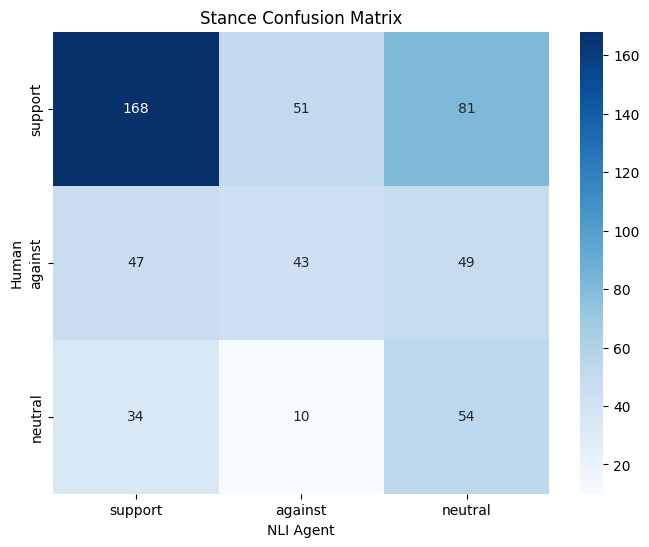

In [35]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.197
Macro-F1 Score: 0.450

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.41      0.31      0.35       139
     neutral       0.29      0.57      0.39        98
     support       0.68      0.55      0.61       300

    accuracy                           0.49       537
   macro avg       0.46      0.48      0.45       537
weighted avg       0.54      0.49      0.50       537



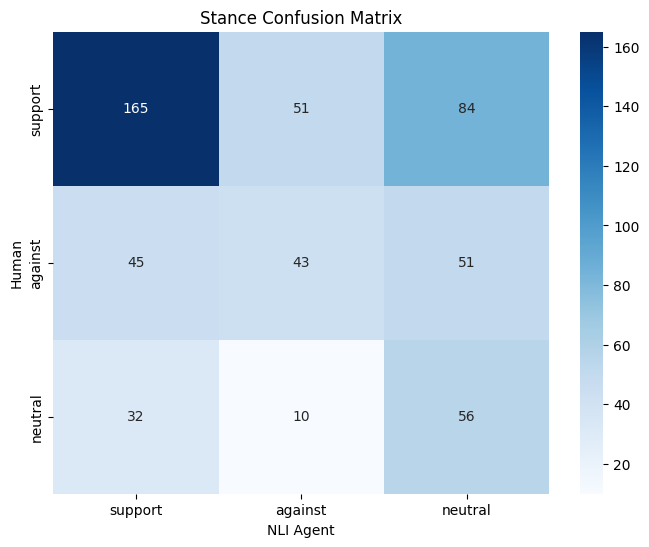

In [53]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.209
Macro-F1 Score: 0.459

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.43      0.33      0.37       139
     neutral       0.30      0.57      0.39        98
     support       0.69      0.55      0.61       300

    accuracy                           0.50       537
   macro avg       0.47      0.49      0.46       537
weighted avg       0.55      0.50      0.51       537



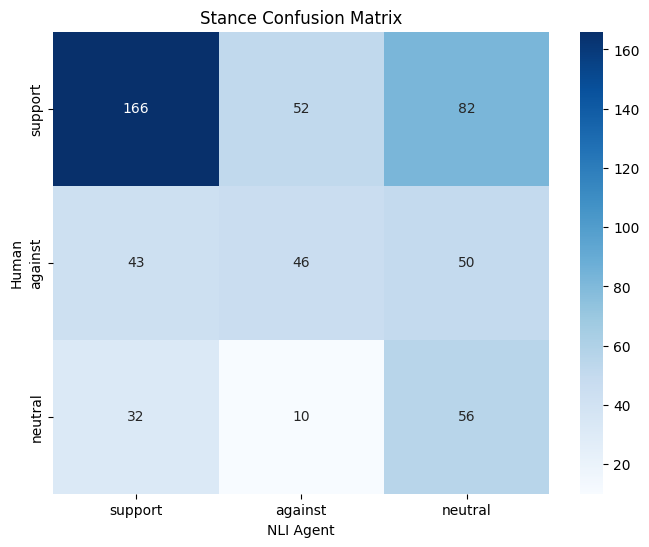

In [59]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.197
Macro-F1 Score: 0.450

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.41      0.31      0.35       139
     neutral       0.29      0.57      0.39        98
     support       0.68      0.55      0.61       300

    accuracy                           0.49       537
   macro avg       0.46      0.48      0.45       537
weighted avg       0.54      0.49      0.50       537



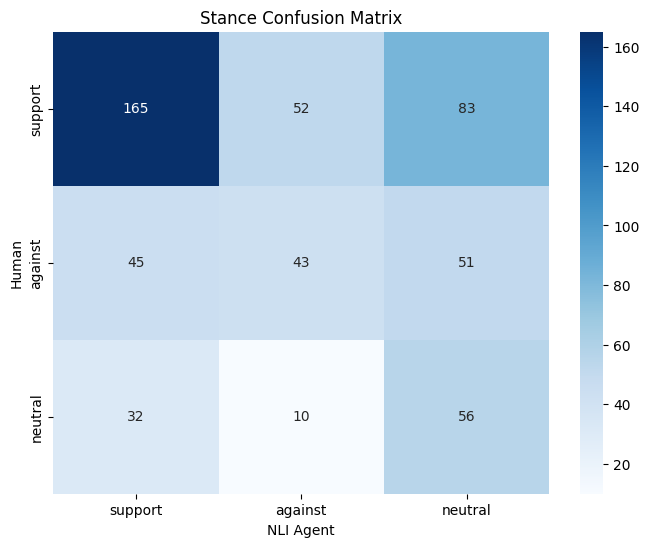

In [88]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.217
Macro-F1 Score: 0.462

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.43      0.32      0.37       141
     neutral       0.29      0.62      0.40        91
     support       0.70      0.56      0.62       305

    accuracy                           0.50       537
   macro avg       0.48      0.50      0.46       537
weighted avg       0.56      0.50      0.52       537



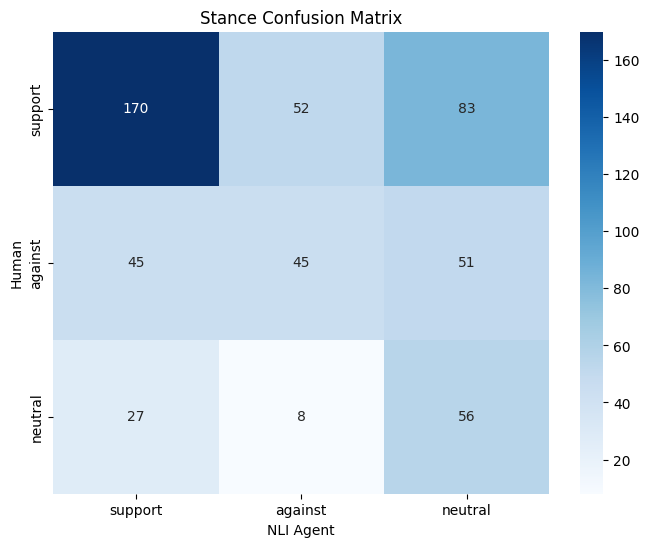

In [99]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.268
Macro-F1 Score: 0.498

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.46      0.35      0.40       136
     neutral       0.34      0.70      0.45        92
     support       0.73      0.57      0.64       309

    accuracy                           0.54       537
   macro avg       0.51      0.54      0.50       537
weighted avg       0.59      0.54      0.55       537



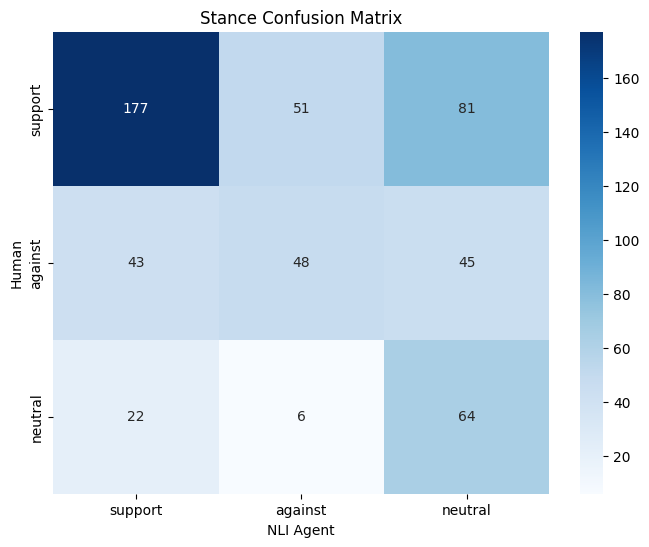

In [111]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.355
Macro-F1 Score: 0.556

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.50      0.41      0.45       130
     neutral       0.38      0.83      0.53        88
     support       0.80      0.61      0.69       319

    accuracy                           0.60       537
   macro avg       0.56      0.62      0.56       537
weighted avg       0.66      0.60      0.61       537



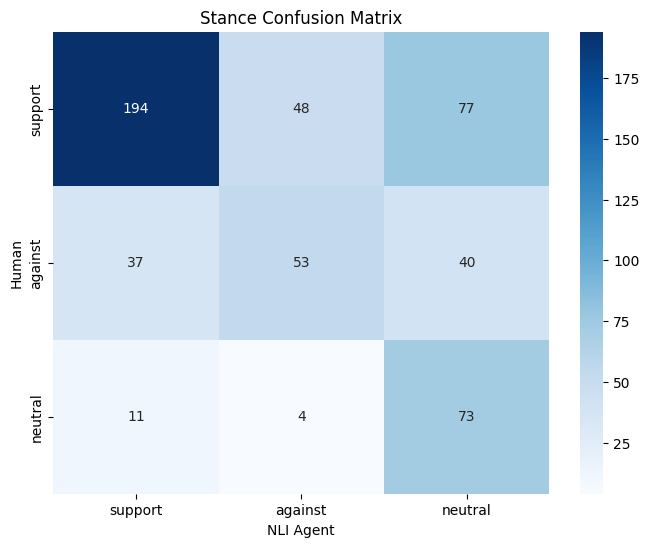

In [124]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.42
Macro-F1 Score: 0.60

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.53      0.44      0.48       126
     neutral       0.43      0.91      0.58        89
     support       0.84      0.63      0.72       322

    accuracy                           0.64       537
   macro avg       0.60      0.66      0.60       537
weighted avg       0.70      0.64      0.64       537



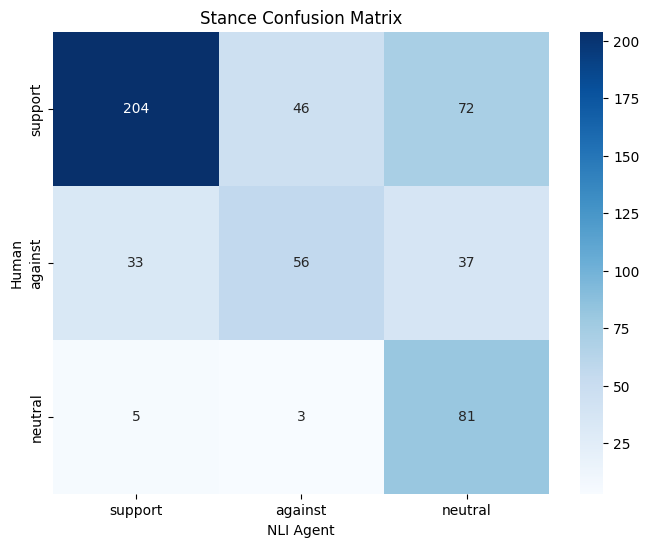

In [137]:
evaluate_alignment(true_labels, nli_labels)

In [16]:
def get_stance(excerpt, category_code, definitions):    
    supercat=category_code - (category_code%100)
    
    relevance_labels = ["taking a stance", "neutral or purely descriptive"]
    relevance_template = f"Regarding {titles[category_code]}, this speaker is {{}}."
    rel_result = classifier(excerpt, relevance_labels, hypothesis_template=relevance_template)
    
    if rel_result['labels'][0] == "neutral or purely descriptive":
        return "neutral", rel_result['scores'][0]
    
    support_def = definitions[category_code]['support'] # e.g. Tax increases
    against_def = definitions[category_code]['against'] # e.g. Tax reductions    
    
    if support_def=="" and against_def=="":
        return "neutral", 1.0            
    
    label_map = {
        support_def: "support",
        against_def: "against"        
    }
    
    candidate_labels = list(label_map.keys())

    hypothesis_template = f"The speaker's position on {titles[category_code]} is best described as {{}}."
        
    result = classifier(excerpt, candidate_labels, hypothesis_template=hypothesis_template)
        
    final_label = label_map[result['labels'][0]]
    return final_label, result['scores'][0]

In [203]:
nli_labels = []
confidence_scores = []
for index, row in stance_df.iterrows():
    print(f"{index} / {len(stance_df)}")
    label, con_score = get_stance(row['Text'], int(row['Claim_Labels']), definitions)
    nli_labels.append(label)
    confidence_scores.append(con_score)
    print("")

0 / 537

1 / 537

2 / 537

3 / 537

4 / 537

5 / 537

6 / 537

7 / 537

8 / 537

10 / 537

11 / 537

12 / 537

13 / 537

14 / 537

15 / 537

16 / 537

17 / 537

18 / 537

19 / 537

20 / 537

21 / 537

22 / 537

23 / 537

24 / 537

25 / 537

26 / 537

27 / 537

28 / 537

29 / 537

30 / 537

31 / 537

32 / 537

33 / 537

34 / 537

35 / 537

36 / 537

37 / 537

38 / 537

39 / 537

40 / 537

41 / 537

42 / 537

43 / 537

45 / 537

46 / 537

47 / 537

48 / 537

49 / 537

50 / 537

51 / 537

52 / 537

53 / 537

54 / 537

55 / 537

56 / 537

57 / 537

58 / 537

59 / 537

60 / 537

61 / 537

62 / 537

63 / 537

64 / 537

65 / 537

66 / 537

67 / 537

68 / 537

69 / 537

70 / 537

71 / 537

72 / 537

73 / 537

74 / 537

75 / 537

76 / 537

77 / 537

78 / 537

79 / 537

80 / 537

81 / 537

82 / 537

83 / 537

84 / 537

85 / 537

86 / 537

87 / 537

88 / 537

89 / 537

90 / 537

91 / 537

92 / 537

93 / 537

94 / 537

95 / 537

96 / 537

97 / 537

98 / 537

99 / 537

100 / 537

101 / 537

102 / 5

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.32
Macro-F1 Score: 0.53

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.39      0.69      0.50       126
     neutral       0.62      0.26      0.37        89
     support       0.78      0.67      0.72       322

    accuracy                           0.61       537
   macro avg       0.60      0.54      0.53       537
weighted avg       0.66      0.61      0.61       537



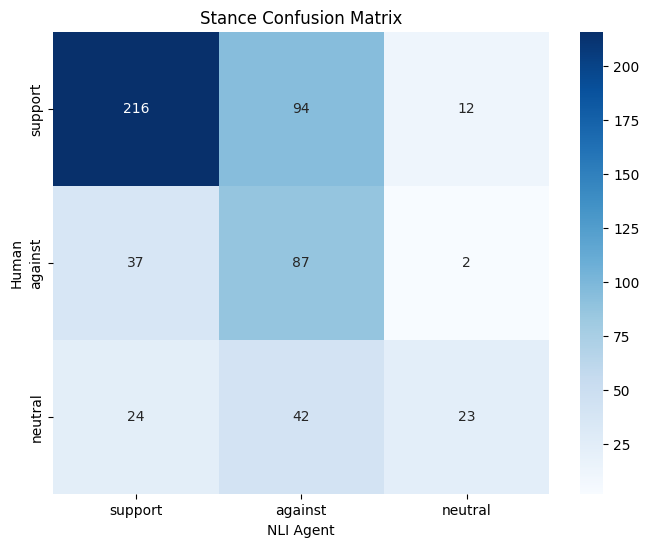

In [156]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.41
Macro-F1 Score: 0.59

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.48      0.75      0.58       141
     neutral       0.68      0.32      0.44        77
     support       0.81      0.70      0.75       319

    accuracy                           0.66       537
   macro avg       0.65      0.59      0.59       537
weighted avg       0.70      0.66      0.66       537



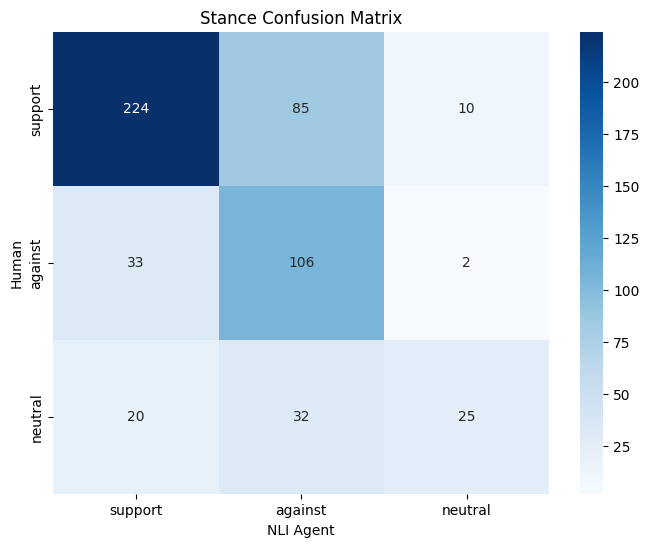

In [193]:
evaluate_alignment(true_labels, nli_labels)

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.54
Macro-F1 Score: 0.72

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.57      0.81      0.67       156
     neutral       0.81      0.58      0.67        52
     support       0.88      0.74      0.80       329

    accuracy                           0.74       537
   macro avg       0.75      0.71      0.72       537
weighted avg       0.78      0.74      0.75       537



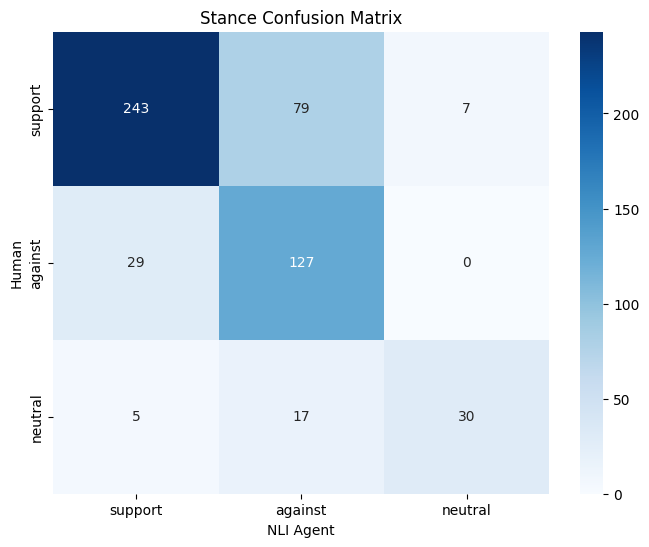

In [204]:
evaluate_alignment(true_labels, nli_labels)

In [17]:
model_name = "facebook/bart-large-mnli"
classifier = pipeline("zero-shot-classification", model=model_name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [18]:
def get_stance(excerpt, category_code, definitions):    
    supercat=category_code - (category_code%100)
    
    relevance_labels = ["taking a stance", "neutral or purely descriptive"]
    relevance_template = f"Regarding {titles[category_code]}, this speaker is {{}}."
    rel_result = classifier(excerpt, relevance_labels, hypothesis_template=relevance_template)
    
    if rel_result['labels'][0] == "neutral or purely descriptive":
        return "neutral", rel_result['scores'][0]
    
    support_def = definitions[category_code]['support'] # e.g. Tax increases
    against_def = definitions[category_code]['against'] # e.g. Tax reductions    
    
    if support_def=="" and against_def=="":
        return "neutral", 1.0            
    
    label_map = {
        support_def: "support",
        against_def: "against"        
    }
    
    candidate_labels = list(label_map.keys())

    hypothesis_template = f"The speaker's position on {titles[category_code]} is best described as {{}}."
        
    result = classifier(excerpt, candidate_labels, hypothesis_template=hypothesis_template)
        
    final_label = label_map[result['labels'][0]]
    return final_label, result['scores'][0]

In [20]:
%%notify
nli_labels = []
confidence_scores = []
for index, row in stance_df.iterrows():
    print(f"{index} / {len(stance_df)}")
    label, con_score = get_stance(row['Text'], int(row['Claim_Labels']), definitions)
    nli_labels.append(label)
    confidence_scores.append(con_score)
    print("")

0 / 537

1 / 537

2 / 537

3 / 537

4 / 537


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



5 / 537

6 / 537

7 / 537

8 / 537

10 / 537

11 / 537

12 / 537

13 / 537

14 / 537

15 / 537

16 / 537

17 / 537

18 / 537

19 / 537

20 / 537

21 / 537

22 / 537

23 / 537

24 / 537

25 / 537

26 / 537

27 / 537

28 / 537

29 / 537

30 / 537

31 / 537

32 / 537

33 / 537

34 / 537

35 / 537

36 / 537

37 / 537

38 / 537

39 / 537

40 / 537

41 / 537

42 / 537

43 / 537

45 / 537

46 / 537

47 / 537

48 / 537

49 / 537

50 / 537

51 / 537

52 / 537

53 / 537

54 / 537

55 / 537

56 / 537

57 / 537

58 / 537

59 / 537

60 / 537

61 / 537

62 / 537

63 / 537

64 / 537

65 / 537

66 / 537

67 / 537

68 / 537

69 / 537

70 / 537

71 / 537

72 / 537

73 / 537

74 / 537

75 / 537

76 / 537

77 / 537

78 / 537

79 / 537

80 / 537

81 / 537

82 / 537

83 / 537

84 / 537

85 / 537

86 / 537

87 / 537

88 / 537

89 / 537

90 / 537

91 / 537

92 / 537

93 / 537

94 / 537

95 / 537

96 / 537

97 / 537

98 / 537

99 / 537

100 / 537

101 / 537

102 / 537

103 / 537

104 / 537

105 / 537

106 / 5

<IPython.core.display.Javascript object>

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.48
Macro-F1 Score: 0.65

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.58      0.72      0.64       156
     neutral       1.00      0.35      0.51        52
     support       0.80      0.80      0.80       329

    accuracy                           0.73       537
   macro avg       0.79      0.62      0.65       537
weighted avg       0.76      0.73      0.73       537



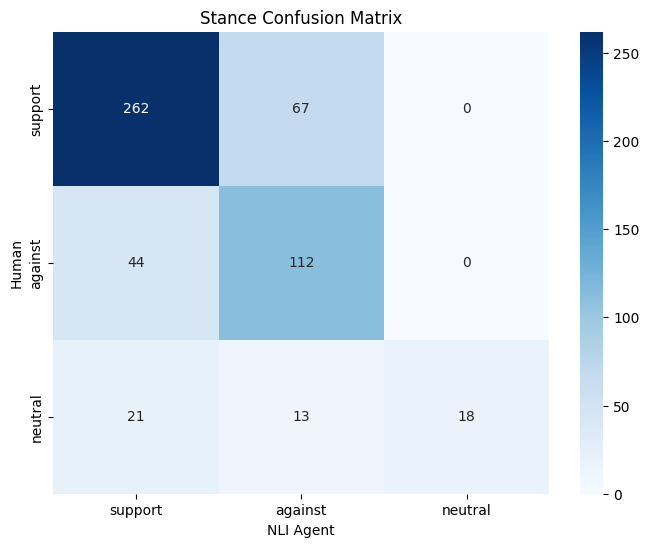

In [23]:
evaluate_alignment(true_labels, nli_labels)

In [13]:
model_name = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
classifier = pipeline("zero-shot-classification", model=model_name)

def get_stance(excerpt, category_code, definitions):    
    supercat=category_code - (category_code%100)
    
    relevance_labels = ["taking a stance", "neutral or purely descriptive"]
    relevance_template = f"Regarding {titles[category_code]}, this speaker is {{}}."
    rel_result = classifier(excerpt, relevance_labels, hypothesis_template=relevance_template)
    
    if rel_result['labels'][0] == "neutral or purely descriptive":
        return "neutral", rel_result['scores'][0]
    
    support_def = definitions[category_code]['support'] # e.g. Tax increases
    against_def = definitions[category_code]['against'] # e.g. Tax reductions    
    
    if support_def=="" and against_def=="":
        return "neutral", 1.0            
    
    label_map = {
        support_def: "support",
        against_def: "against"        
    }
    
    candidate_labels = list(label_map.keys())

    hypothesis_template = f"The speaker's position on {titles[category_code]} is best described as {{}}."
        
    result = classifier(excerpt, candidate_labels, hypothesis_template=hypothesis_template)
        
    final_label = label_map[result['labels'][0]]
    return final_label, result['scores'][0]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cuda:0


In [21]:
%%notify
nli_labels = []
confidence_scores = []
for index, row in stance_df.iterrows():
    print(f"{index} / {len(stance_df)}")
    label, con_score = get_stance(row['Text'], int(row['Claim_Labels']), definitions)
    nli_labels.append(label)
    confidence_scores.append(con_score)
    print("")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


0 / 537

1 / 537

2 / 537

3 / 537

4 / 537


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



5 / 537

6 / 537

7 / 537

8 / 537

10 / 537

11 / 537

12 / 537

13 / 537

14 / 537

15 / 537

16 / 537

17 / 537

18 / 537

19 / 537

20 / 537

21 / 537

22 / 537

23 / 537

24 / 537

25 / 537

26 / 537

27 / 537

28 / 537

29 / 537

30 / 537

31 / 537

32 / 537

33 / 537

34 / 537

35 / 537

36 / 537

37 / 537

38 / 537

39 / 537

40 / 537

41 / 537

42 / 537

43 / 537

45 / 537

46 / 537

47 / 537

48 / 537

49 / 537

50 / 537

51 / 537

52 / 537

53 / 537

54 / 537

55 / 537

56 / 537

57 / 537

58 / 537

59 / 537

60 / 537

61 / 537

62 / 537

63 / 537

64 / 537

65 / 537

66 / 537

67 / 537

68 / 537

69 / 537

70 / 537

71 / 537

72 / 537

73 / 537

74 / 537

75 / 537

76 / 537

77 / 537

78 / 537

79 / 537

80 / 537

81 / 537

82 / 537

83 / 537

84 / 537

85 / 537

86 / 537

87 / 537

88 / 537

89 / 537

90 / 537

91 / 537

92 / 537

93 / 537

94 / 537

95 / 537

96 / 537

97 / 537

98 / 537

99 / 537

100 / 537

101 / 537

102 / 537

103 / 537

104 / 537

105 / 537

106 / 5

<IPython.core.display.Javascript object>

Alignment Metrics ---------
Inter-Rater Agreement (Cohen's Kappa): 0.52
Macro-F1 Score: 0.64

Detailed Classification Report:
              precision    recall  f1-score   support

     against       0.67      0.71      0.69       156
     neutral       0.40      0.38      0.39        52
     support       0.83      0.82      0.82       329

    accuracy                           0.74       537
   macro avg       0.64      0.64      0.64       537
weighted avg       0.74      0.74      0.74       537



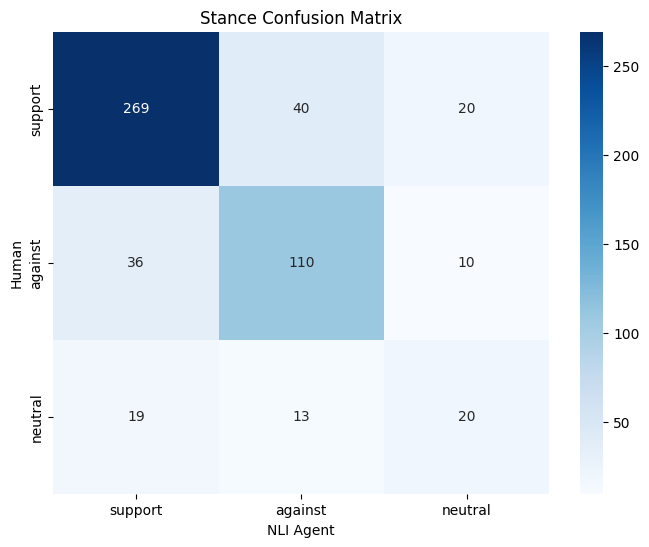

In [24]:
evaluate_alignment(true_labels, nli_labels)

In [47]:
df_index = []
for index, row in stance_df.iterrows():
    print(index)
    df_index.append(index)

0
1
2
3
4
5
6
7
8
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278

In [48]:
len(df_index)

537

In [157]:
for i in range(len(true_labels)):
    if true_labels[i] != nli_labels[i]:
        print(f"Human labelled {true_labels[i]}, NLI labelled {nli_labels[i]}, for {stance_df.at[df_index[i], 'Claim_Labels']}")   
        print(f"ID: {stance_df.at[df_index[i], 'ID']} Text:\"{stance_df.at[df_index[i], 'Text']}\"")
        print("")

Human labelled support, NLI labelled against, for 1211
ID: 0 Text:"So knife crime's going to go up, because the evidence is there, Carla. Reduce stop-and-search, knife crime soars. No, it doesn't."

Human labelled against, NLI labelled support, for 107
ID: 1 Text:"Of course Gordon Brown's right to say there's a link. Michael, you know this better than we do. You know there's a link between poverty at home and underperformance in the classroom. It's that link which is holding back so many children. That's what's unfair. That link is the link that I want to help solve. We would do it partly through the tax proposals I've talked about earlier, giving people £700 back in their pocket by raising the income tax threshold to £10,000 so that people on ordinary incomes who aren't being helped at the moment are helped. And through our proposal, we call it - it's a slightly technocratic phrase - we call it a pupil premium. It basically means extra money, £2.5 billion. That would, for instance, al

In [205]:
# pseudo-labelling the rest of the data.
# taking the high-confidence predictions
# need the text, ids, topic labels, then stance will be predicted
# pre-training outcome should be text,individual topic, stance, confidence

In [3]:
#import train.csv
train_df = pd.read_csv('../Identifying Topics/train_df.csv', index_col=0)
train_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [4]:
# remove the rows without topics
train_df = train_df.loc[~(train_df['claim_labels']=='[]')]
train_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
5,Well it depends whether you're talking about t...,"[100, 107]"
9,Is the ERM writ large with no exit signs.,[1900]
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [5]:
def remove_brackets(codes):
    return codes[1:-1]

In [6]:
def filter_labels(label_list):
        return [
            item for item in label_list 
            if item.isdigit() and int(item) % 100 != 0
        ]

In [7]:
tmp_df = train_df.copy()
tmp_df['claim_labels'] = tmp_df['claim_labels'].apply(remove_brackets)
tmp_df['claim_labels'] = tmp_df['claim_labels'].fillna('').astype(str).str.split(r'\s*,\s*')
tmp_df['claim_labels'] = tmp_df['claim_labels'].apply(filter_labels)
tmp_df = tmp_df.explode('claim_labels')
tmp_df = tmp_df.dropna(subset=['claim_labels'])
tmp_df = tmp_df[tmp_df['claim_labels'] != '']
tmp_df.reset_index(drop=True, inplace=True)
tmp_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...",230
1,I think this is partly what's been going wrong...,230
2,No. I want to be a member of the European Unio...,1910
3,Well it depends whether you're talking about t...,107
4,But you are right when you say that you can't ...,230
...,...,...
4117,"Terry, like so many people around the country,...",107
4118,"Terry, like so many people around the country,...",325
4119,"Yeah, I was incredibly sad to have caused peop...",1609
4120,There are lots of people who go for private he...,108


In [25]:
print(2)

2


In [8]:
train_df = tmp_df
train_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...",230
1,I think this is partly what's been going wrong...,230
2,No. I want to be a member of the European Unio...,1910
3,Well it depends whether you're talking about t...,107
4,But you are right when you say that you can't ...,230
...,...,...
4117,"Terry, like so many people around the country,...",107
4118,"Terry, like so many people around the country,...",325
4119,"Yeah, I was incredibly sad to have caused peop...",1609
4120,There are lots of people who go for private he...,108


In [9]:
tmp_df = train_df.copy()
tmp_df = tmp_df[tmp_df['claim_labels'] != '608']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1906']
tmp_df = tmp_df[tmp_df['claim_labels'] != '203']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1009']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1903']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1301']
tmp_df = tmp_df[tmp_df['claim_labels'] != '2007']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1402']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1212']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1306']
tmp_df = tmp_df[tmp_df['claim_labels'] != '706']
tmp_df = tmp_df[tmp_df['claim_labels'] != '1309']
tmp_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...",230
1,I think this is partly what's been going wrong...,230
2,No. I want to be a member of the European Unio...,1910
3,Well it depends whether you're talking about t...,107
4,But you are right when you say that you can't ...,230
...,...,...
4117,"Terry, like so many people around the country,...",107
4118,"Terry, like so many people around the country,...",325
4119,"Yeah, I was incredibly sad to have caused peop...",1609
4120,There are lots of people who go for private he...,108


In [10]:
train_df=tmp_df
train_df

,text,claim_labels
0,"Of course, we have to improve the system, but ...",230
1,I think this is partly what's been going wrong...,230
2,No. I want to be a member of the European Unio...,1910
3,Well it depends whether you're talking about t...,107
4,But you are right when you say that you can't ...,230
...,...,...
4117,"Terry, like so many people around the country,...",107
4118,"Terry, like so many people around the country,...",325
4119,"Yeah, I was incredibly sad to have caused peop...",1609
4120,There are lots of people who go for private he...,108


In [17]:
nli_train_labels = []
confidence_train_scores = []
for index, row in train_df.iterrows():
    print(f"{index} / {len(train_df)}")
    label, con_score = get_stance(row['text'], int(row['claim_labels']), definitions)
    nli_train_labels.append(label)
    confidence_train_scores.append(con_score)
    print("")

0 / 4097

1 / 4097

2 / 4097

3 / 4097

4 / 4097

5 / 4097


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



6 / 4097

7 / 4097

8 / 4097

9 / 4097

10 / 4097

11 / 4097

12 / 4097

13 / 4097

14 / 4097

15 / 4097

16 / 4097

17 / 4097

18 / 4097

19 / 4097

20 / 4097

21 / 4097

22 / 4097

23 / 4097

24 / 4097

25 / 4097

26 / 4097

27 / 4097

28 / 4097

29 / 4097

30 / 4097

31 / 4097

32 / 4097

33 / 4097

34 / 4097

35 / 4097

36 / 4097

37 / 4097

38 / 4097

39 / 4097

40 / 4097

41 / 4097

42 / 4097

43 / 4097

44 / 4097

45 / 4097

46 / 4097

47 / 4097

48 / 4097

49 / 4097

50 / 4097

51 / 4097

52 / 4097

53 / 4097

54 / 4097

55 / 4097

56 / 4097

57 / 4097

58 / 4097

59 / 4097

60 / 4097

61 / 4097

62 / 4097

63 / 4097

64 / 4097

65 / 4097

66 / 4097

67 / 4097

68 / 4097

69 / 4097

70 / 4097

71 / 4097

72 / 4097

73 / 4097

74 / 4097

75 / 4097

76 / 4097

77 / 4097

78 / 4097

79 / 4097

80 / 4097

81 / 4097

82 / 4097

83 / 4097

84 / 4097

85 / 4097

86 / 4097

87 / 4097

88 / 4097

89 / 4097

90 / 4097

91 / 4097

92 / 4097

93 / 4097

94 / 4097

95 / 4097

96 / 4097

97


701 / 4097

702 / 4097

703 / 4097

704 / 4097

705 / 4097

706 / 4097

707 / 4097

708 / 4097

709 / 4097

710 / 4097

711 / 4097

712 / 4097

713 / 4097

714 / 4097

715 / 4097

716 / 4097

717 / 4097

718 / 4097

719 / 4097

720 / 4097

721 / 4097

722 / 4097

723 / 4097

724 / 4097

725 / 4097

726 / 4097

727 / 4097

728 / 4097

729 / 4097

730 / 4097

731 / 4097

732 / 4097

733 / 4097

734 / 4097

735 / 4097

736 / 4097

737 / 4097

738 / 4097

739 / 4097

740 / 4097

741 / 4097

742 / 4097

743 / 4097

744 / 4097

745 / 4097

746 / 4097

747 / 4097

748 / 4097

749 / 4097

750 / 4097

751 / 4097

752 / 4097

753 / 4097

754 / 4097

755 / 4097

756 / 4097

757 / 4097

758 / 4097

759 / 4097

760 / 4097

761 / 4097

762 / 4097

763 / 4097

764 / 4097

765 / 4097

766 / 4097

767 / 4097

768 / 4097

769 / 4097

770 / 4097

771 / 4097

772 / 4097

773 / 4097

774 / 4097

775 / 4097

776 / 4097

777 / 4097

778 / 4097

779 / 4097

780 / 4097

781 / 4097

782 / 4097

783 / 4097

784


1357 / 4097

1358 / 4097

1359 / 4097

1360 / 4097

1361 / 4097

1362 / 4097

1363 / 4097

1364 / 4097

1365 / 4097

1366 / 4097

1367 / 4097

1368 / 4097

1369 / 4097

1370 / 4097

1371 / 4097

1372 / 4097

1373 / 4097

1374 / 4097

1375 / 4097

1376 / 4097

1377 / 4097

1378 / 4097

1379 / 4097

1380 / 4097

1381 / 4097

1382 / 4097

1383 / 4097

1384 / 4097

1385 / 4097

1386 / 4097

1387 / 4097

1388 / 4097

1389 / 4097

1390 / 4097

1391 / 4097

1392 / 4097

1393 / 4097

1394 / 4097

1395 / 4097

1396 / 4097

1397 / 4097

1398 / 4097

1399 / 4097

1400 / 4097

1401 / 4097

1402 / 4097

1403 / 4097

1404 / 4097

1405 / 4097

1406 / 4097

1407 / 4097

1408 / 4097

1409 / 4097

1410 / 4097

1411 / 4097

1412 / 4097

1413 / 4097

1414 / 4097

1415 / 4097

1416 / 4097

1417 / 4097

1418 / 4097

1419 / 4097

1420 / 4097

1421 / 4097

1422 / 4097

1423 / 4097

1424 / 4097

1425 / 4097

1426 / 4097

1427 / 4097

1428 / 4097

1429 / 4097

1430 / 4097

1431 / 4097

1432 / 4097

1433 / 4097


1990 / 4097

1991 / 4097

1992 / 4097

1993 / 4097

1994 / 4097

1995 / 4097

1996 / 4097

1997 / 4097

1998 / 4097

1999 / 4097

2000 / 4097

2001 / 4097

2002 / 4097

2003 / 4097

2004 / 4097

2005 / 4097

2006 / 4097

2007 / 4097

2008 / 4097

2009 / 4097

2010 / 4097

2011 / 4097

2012 / 4097

2013 / 4097

2014 / 4097

2015 / 4097

2016 / 4097

2017 / 4097

2018 / 4097

2019 / 4097

2020 / 4097

2021 / 4097

2022 / 4097

2023 / 4097

2024 / 4097

2025 / 4097

2026 / 4097

2027 / 4097

2028 / 4097

2029 / 4097

2030 / 4097

2031 / 4097

2032 / 4097

2033 / 4097

2034 / 4097

2035 / 4097

2036 / 4097

2037 / 4097

2038 / 4097

2039 / 4097

2040 / 4097

2041 / 4097

2042 / 4097

2043 / 4097

2044 / 4097

2045 / 4097

2046 / 4097

2047 / 4097

2048 / 4097

2049 / 4097

2050 / 4097

2051 / 4097

2052 / 4097

2053 / 4097

2054 / 4097

2055 / 4097

2056 / 4097

2057 / 4097

2058 / 4097

2059 / 4097

2060 / 4097

2061 / 4097

2062 / 4097

2063 / 4097

2064 / 4097

2065 / 4097

2066 / 4097


2627 / 4097

2628 / 4097

2629 / 4097

2630 / 4097

2631 / 4097

2632 / 4097

2633 / 4097

2634 / 4097

2635 / 4097

2636 / 4097

2637 / 4097

2638 / 4097

2639 / 4097

2640 / 4097

2641 / 4097

2642 / 4097

2643 / 4097

2644 / 4097

2645 / 4097

2646 / 4097

2647 / 4097

2648 / 4097

2649 / 4097

2650 / 4097

2651 / 4097

2652 / 4097

2653 / 4097

2654 / 4097

2655 / 4097

2656 / 4097

2657 / 4097

2658 / 4097

2659 / 4097

2660 / 4097

2661 / 4097

2662 / 4097

2663 / 4097

2664 / 4097

2665 / 4097

2666 / 4097

2667 / 4097

2668 / 4097

2669 / 4097

2670 / 4097

2671 / 4097

2672 / 4097

2673 / 4097

2674 / 4097

2675 / 4097

2676 / 4097

2677 / 4097

2678 / 4097

2679 / 4097

2680 / 4097

2681 / 4097

2682 / 4097

2683 / 4097

2684 / 4097

2685 / 4097

2686 / 4097

2687 / 4097

2688 / 4097

2689 / 4097

2690 / 4097

2691 / 4097

2692 / 4097

2693 / 4097

2694 / 4097

2695 / 4097

2696 / 4097

2697 / 4097

2698 / 4097

2699 / 4097

2700 / 4097

2701 / 4097

2702 / 4097

2703 / 4097


3262 / 4097

3263 / 4097

3264 / 4097

3265 / 4097

3266 / 4097

3267 / 4097

3268 / 4097

3269 / 4097

3270 / 4097

3271 / 4097

3272 / 4097

3273 / 4097

3274 / 4097

3275 / 4097

3276 / 4097

3277 / 4097

3278 / 4097

3279 / 4097

3280 / 4097

3281 / 4097

3282 / 4097

3283 / 4097

3284 / 4097

3285 / 4097

3286 / 4097

3287 / 4097

3288 / 4097

3289 / 4097

3290 / 4097

3291 / 4097

3292 / 4097

3293 / 4097

3294 / 4097

3295 / 4097

3296 / 4097

3297 / 4097

3298 / 4097

3299 / 4097

3300 / 4097

3301 / 4097

3302 / 4097

3303 / 4097

3304 / 4097

3305 / 4097

3306 / 4097

3307 / 4097

3308 / 4097

3309 / 4097

3310 / 4097

3311 / 4097

3312 / 4097

3313 / 4097

3314 / 4097

3315 / 4097

3316 / 4097

3317 / 4097

3318 / 4097

3319 / 4097

3320 / 4097

3321 / 4097

3322 / 4097

3323 / 4097

3324 / 4097

3325 / 4097

3326 / 4097

3327 / 4097

3328 / 4097

3329 / 4097

3330 / 4097

3331 / 4097

3332 / 4097

3333 / 4097

3334 / 4097

3335 / 4097

3336 / 4097

3337 / 4097

3338 / 4097


3902 / 4097

3903 / 4097

3904 / 4097

3906 / 4097

3907 / 4097

3908 / 4097

3909 / 4097

3910 / 4097

3911 / 4097

3912 / 4097

3913 / 4097

3914 / 4097

3915 / 4097

3916 / 4097

3917 / 4097

3918 / 4097

3919 / 4097

3920 / 4097

3922 / 4097

3923 / 4097

3924 / 4097

3925 / 4097

3926 / 4097

3927 / 4097

3928 / 4097

3929 / 4097

3930 / 4097

3931 / 4097

3932 / 4097

3933 / 4097

3934 / 4097

3935 / 4097

3936 / 4097

3937 / 4097

3938 / 4097

3939 / 4097

3940 / 4097

3941 / 4097

3942 / 4097

3943 / 4097

3944 / 4097

3945 / 4097

3946 / 4097

3947 / 4097

3948 / 4097

3949 / 4097

3950 / 4097

3951 / 4097

3952 / 4097

3953 / 4097

3954 / 4097

3955 / 4097

3956 / 4097

3957 / 4097

3958 / 4097

3959 / 4097

3960 / 4097

3961 / 4097

3962 / 4097

3963 / 4097

3964 / 4097

3965 / 4097

3966 / 4097

3967 / 4097

3968 / 4097

3969 / 4097

3970 / 4097

3971 / 4097

3972 / 4097

3973 / 4097

3974 / 4097

3975 / 4097

3976 / 4097

3977 / 4097

3978 / 4097

3979 / 4097

3980 / 4097

In [20]:
len(confidence_train_scores)

4097

In [21]:
tmp_df = train_df.copy()
tmp_df['stance'] = nli_train_labels
tmp_df['confidence'] = confidence_train_scores
train_df=tmp_df
train_df

,text,claim_labels,stance,confidence
0,"Of course, we have to improve the system, but ...",230,against,0.853987
1,I think this is partly what's been going wrong...,230,against,0.661541
2,No. I want to be a member of the European Unio...,1910,support,0.827143
3,Well it depends whether you're talking about t...,107,neutral,0.590986
4,But you are right when you say that you can't ...,230,against,0.695967
...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345
4118,"Terry, like so many people around the country,...",325,support,0.860713
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787
4120,There are lots of people who go for private he...,108,support,0.614357


In [22]:
train_df.to_csv("train_stance.csv")

In [25]:
unique_labels_list = train_df['claim_labels'].unique().tolist()
print(unique_labels_list)

['230', '1910', '107', '1920', '601', '105', '301', '2012', '202', '602', '705', '1209', '1303', '1926', '1610', '1608', '1410', '1803', '1302', '1205', '1627', '101', '803', '201', '1907', '2001', '108', '1202', '1211', '529', '701', '703', '806', '103', '508', '1401', '207', '1206', '1603', '2011', '1901', '505', '506', '1406', '1207', '502', '325', '603', '401', '709', '1930', '1304', '1806', '104', '1609', '1208', '504', '1005', '1006', '208', '1203', '1909', '332', '1001', '604', '1407', '1409', '331', '503', '1911', '1305', '408', '801', '406', '344', '2032', '321', '334', '1501', '805', '1521', '1002']


In [39]:
print("Keeping high confidence labels (while ensuring data is sufficient to predict each topic-stance pair)")
for i in unique_labels_list:
    sup_60 = len(train_df.loc[(train_df['claim_labels']==i)&(train_df['confidence']>=0.5)&(train_df['stance']=='support')])
    sup_70 = len(train_df.loc[(train_df['claim_labels']==i)&(train_df['confidence']>=0.7)&(train_df['stance']=='support')])
    sup_85 = len(train_df.loc[(train_df['claim_labels']==i)&(train_df['confidence']>=0.85)&(train_df['stance']=='support')])
    ag_60 = len(train_df.loc[((train_df['claim_labels']==i)&train_df['confidence']>=0.6)&(train_df['stance']=='against')])
    ag_70 = len(train_df.loc[(train_df['claim_labels']==i)&(train_df['confidence']>=0.7)&(train_df['stance']=='against')])
    ag_85 = len(train_df.loc[(train_df['claim_labels']==i)&(train_df['confidence']>=0.85)&(train_df['stance']=='against')])
    print(f"------Label {i}-------")
    print(f"Support: 0.6: {sup_60} values, 0.7: {sup_70} values, 0.85: {sup_85} values")
    print(f"Against: 0.6: {ag_60} values, 0.7: {ag_70} values, 0.85: {ag_85} values")
    print("")


Keeping high confidence labels (while ensuring data is sufficient to predict each topic-stance pair)
------Label 230-------
Support: 0.6: 8 values, 0.7: 4 values, 0.85: 0 values
Against: 0.6: 204 values, 0.7: 126 values, 0.85: 41 values

------Label 1910-------
Support: 0.6: 73 values, 0.7: 48 values, 0.85: 18 values
Against: 0.6: 109 values, 0.7: 50 values, 0.85: 17 values

------Label 107-------
Support: 0.6: 81 values, 0.7: 52 values, 0.85: 26 values
Against: 0.6: 174 values, 0.7: 68 values, 0.85: 30 values

------Label 1920-------
Support: 0.6: 23 values, 0.7: 15 values, 0.85: 6 values
Against: 0.6: 26 values, 0.7: 13 values, 0.85: 4 values

------Label 601-------
Support: 0.6: 23 values, 0.7: 17 values, 0.85: 10 values
Against: 0.6: 14 values, 0.7: 7 values, 0.85: 2 values

------Label 105-------
Support: 0.6: 131 values, 0.7: 34 values, 0.85: 2 values
Against: 0.6: 194 values, 0.7: 15 values, 0.85: 1 values

------Label 301-------
Support: 0.6: 134 values, 0.7: 115 values, 0.85: 

In [48]:
train_df = train_df.loc[(train_df['confidence']>=0.55)]

In [49]:
train_df

,text,claim_labels,stance,confidence
0,"Of course, we have to improve the system, but ...",230,against,0.853987
1,I think this is partly what's been going wrong...,230,against,0.661541
2,No. I want to be a member of the European Unio...,1910,support,0.827143
3,Well it depends whether you're talking about t...,107,neutral,0.590986
4,But you are right when you say that you can't ...,230,against,0.695967
...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345
4118,"Terry, like so many people around the country,...",325,support,0.860713
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787
4120,There are lots of people who go for private he...,108,support,0.614357


In [50]:
train_df['topic_title'] = train_df['claim_labels'].map(titles)
train_df

/tmp/ipykernel_1433013/1536937896.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['topic_title'] = train_df['claim_labels'].map(titles)


,text,claim_labels,stance,confidence,topic_title
0,"Of course, we have to improve the system, but ...",230,against,0.853987,NaN
1,I think this is partly what's been going wrong...,230,against,0.661541,NaN
2,No. I want to be a member of the European Unio...,1910,support,0.827143,NaN
3,Well it depends whether you're talking about t...,107,neutral,0.590986,NaN
4,But you are right when you say that you can't ...,230,against,0.695967,NaN
...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,NaN
4118,"Terry, like so many people around the country,...",325,support,0.860713,NaN
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,NaN
4120,There are lots of people who go for private he...,108,support,0.614357,NaN


In [52]:
tmp_df = train_df.copy()
for index, row in tmp_df.iterrows():
    tmp_df.at[index, "topic_title"] = titles[int(row['claim_labels'])]
tmp_df

,text,claim_labels,stance,confidence,topic_title
0,"Of course, we have to improve the system, but ...",230,against,0.853987,Immigration
1,I think this is partly what's been going wrong...,230,against,0.661541,Immigration
2,No. I want to be a member of the European Unio...,1910,support,0.827143,"Western Europe, Common Market Issues"
3,Well it depends whether you're talking about t...,107,neutral,0.590986,"Taxation, Tax policy, and Tax Reform"
4,But you are right when you say that you can't ...,230,against,0.695967,Immigration
...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,0.860713,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,Veterans Issues
4120,There are lots of people who go for private he...,108,support,0.614357,"Industrial Policy, Privatisation, Nationalisation"


In [53]:
train_df = tmp_df
train_df

,text,claim_labels,stance,confidence,topic_title
0,"Of course, we have to improve the system, but ...",230,against,0.853987,Immigration
1,I think this is partly what's been going wrong...,230,against,0.661541,Immigration
2,No. I want to be a member of the European Unio...,1910,support,0.827143,"Western Europe, Common Market Issues"
3,Well it depends whether you're talking about t...,107,neutral,0.590986,"Taxation, Tax policy, and Tax Reform"
4,But you are right when you say that you can't ...,230,against,0.695967,Immigration
...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,0.860713,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,Veterans Issues
4120,There are lots of people who go for private he...,108,support,0.614357,"Industrial Policy, Privatisation, Nationalisation"


In [54]:
train_df.to_csv('train_stance.csv')

In [65]:
stance_df

,ID,Text,Claim_Labels,Stance
0,0,"So knife crime's going to go up, because the e...",1211,support
1,1,Of course Gordon Brown's right to say there's ...,107,against
2,1,Of course Gordon Brown's right to say there's ...,1302,support
3,1,Of course Gordon Brown's right to say there's ...,602,support
4,1,Of course Gordon Brown's right to say there's ...,603,support
...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support
535,2601,"Well, I share the frustration of both our ques...",230,neutral
536,3070,You're saying people voted for 10% tariffs on ...,1006,support
537,3356,I think this question of enthusiasm is really ...,2032,support


In [67]:
for index, row in stance_df.iterrows():
    stance_df.at[index, "topic_title"] = titles[int(row['Claim_Labels'])]
stance_df

,ID,Text,Claim_Labels,Stance,topic_title
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...


In [71]:
stance_df.rename(columns={'Claim_Labels': 'claim_labels'}, inplace=True)
stance_df.rename(columns={'Stance': 'stance'}, inplace=True)
stance_df.rename(columns={'Text': 'text'}, inplace=True)
stance_df

,ID,text,claim_labels,stance,topic_title
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...


In [72]:
stance_df.to_csv('test_stance.csv')